In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rafi003/healthcare-disease-prediction-dataset/healthcare_disease_prediction_2000.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_curve, auc, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

#  LOAD DATA

In [3]:
df = pd.read_csv('/kaggle/input/datasets/rafi003/healthcare-disease-prediction-dataset/healthcare_disease_prediction_2000.csv')


# EDA

In [4]:
print("\n DATA OVERVIEW")
print(df.shape)
print(df.info())
df.head()


 DATA OVERVIEW
(2000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   BMI                       2000 non-null   float64
 4   Blood_Pressure_Systolic   2000 non-null   int64  
 5   Blood_Pressure_Diastolic  2000 non-null   int64  
 6   Cholesterol               2000 non-null   int64  
 7   Glucose_Level             2000 non-null   int64  
 8   Smoking                   2000 non-null   int64  
 9   Alcohol_Intake            2000 non-null   int64  
 10  Physical_Activity         2000 non-null   int64  
 11  Family_History            2000 non-null   int64  
 12  Heart_Disease             2000 non-null   int64  
 13  Diabetes                  2000 non-n

,Patient_ID,Age,Gender,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,Glucose_Level,Smoking,Alcohol_Intake,Physical_Activity,Family_History,Heart_Disease,Diabetes,Stroke
0,1,69,Male,34.1,127,71,184,154,1,1,0,0,0,1,0
1,2,32,Male,25.0,148,69,177,136,1,1,1,0,0,0,0
2,3,78,Male,25.2,98,93,252,110,0,0,0,0,0,0,0
3,4,38,Male,9.6,162,102,274,87,1,0,1,0,0,0,0
4,5,41,Female,29.0,161,69,251,127,0,1,1,0,0,0,0


In [5]:
print("\n MISSING VALUES")

missing = df.isnull().sum()
print(missing[missing > 0])


 MISSING VALUES
Series([], dtype: int64)


In [6]:
print("\ DUPLICATES")
print("Duplicates:", df.duplicated().sum())

\ DUPLICATES
Duplicates: 0


In [7]:
print("\n SUMMARY STATISTICS")
df.describe()


 SUMMARY STATISTICS


,Patient_ID,Age,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,Glucose_Level,Smoking,Alcohol_Intake,Physical_Activity,Family_History,Heart_Disease,Diabetes,Stroke
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,50.273000,26.977350,134.523500,88.995500,223.980500,132.979500,0.496000,0.503000,0.4950,0.501500,0.080500,0.131000,0.051000
std,577.494589,19.427202,4.945219,26.139856,17.222043,43.212993,37.039574,0.500109,0.500116,0.5001,0.500123,0.272134,0.337485,0.220053
min,1.000000,18.000000,9.600000,90.000000,60.000000,150.000000,70.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,33.750000,23.600000,112.000000,74.000000,187.000000,100.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,50.000000,26.900000,134.500000,89.000000,224.000000,133.000000,0.000000,1.000000,0.0000,1.000000,0.000000,0.000000,0.000000
75%,1500.250000,67.000000,30.500000,158.000000,104.000000,261.000000,165.000000,1.000000,1.000000,1.0000,1.000000,0.000000,0.000000,0.000000
max,2000.000000,84.000000,42.300000,179.000000,119.000000,299.000000,199.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000


In [8]:
targets = ['Heart_Disease','Diabetes','Stroke']


 TARGET DISTRIBUTION


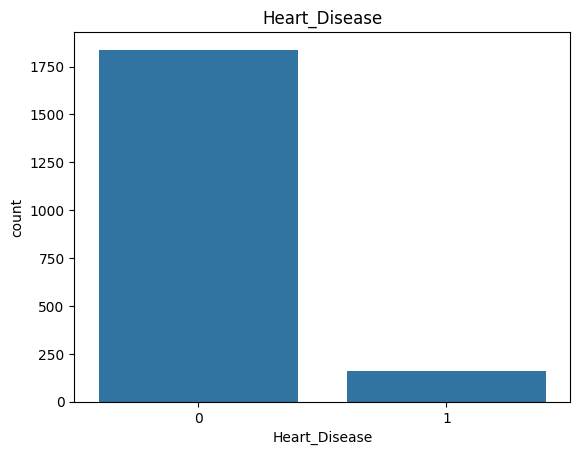

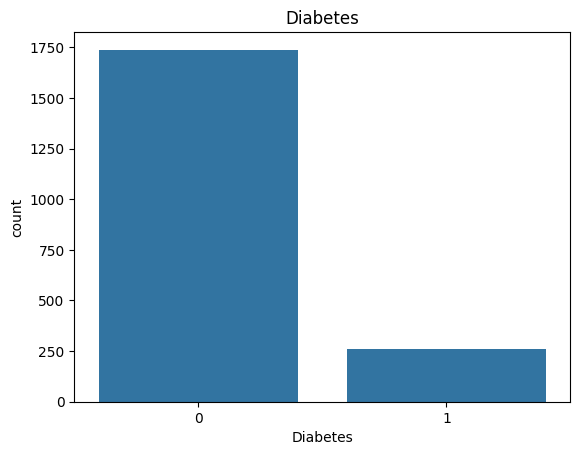

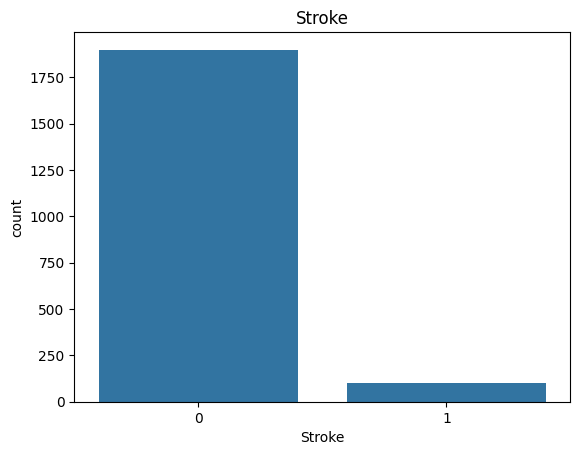

In [9]:
print("\n TARGET DISTRIBUTION")

for col in targets:
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()

In [10]:
print("\n MULTI-LABEL COMBINATIONS")

df['combo'] = df[targets].astype(str).agg(''.join, axis=1)
print(df['combo'].value_counts().head(10))


 MULTI-LABEL COMBINATIONS
combo
000    1547
010     233
100     104
001      48
101      39
110      14
011      11
111       4
Name: count, dtype: int64


In [11]:
features = [
    'Age','Gender','BMI','Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic','Cholesterol','Glucose_Level',
    'Smoking','Alcohol_Intake','Physical_Activity','Family_History'
]



 FEATURE vs DISEASE CORRELATION 


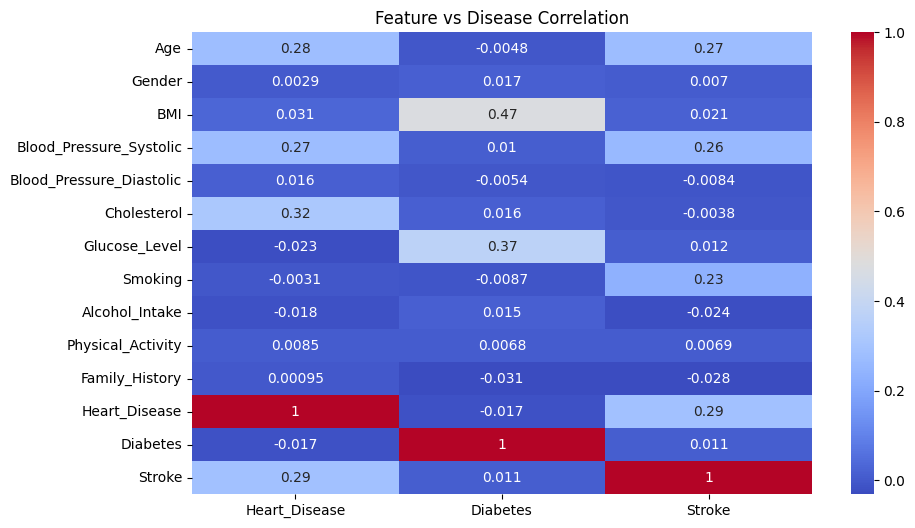

In [12]:
print("\n FEATURE vs DISEASE CORRELATION ")

# ensure numeric only
df_corr = df.copy()

# encode gender 
if df_corr['Gender'].dtype == 'object':
    df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})

plt.figure(figsize=(10,6))

sns.heatmap(
    df_corr[features + targets].corr()[targets],
    cmap="coolwarm",
    annot=True
)

plt.title("Feature vs Disease Correlation")
plt.show()


 AGE DISTRIBUTION


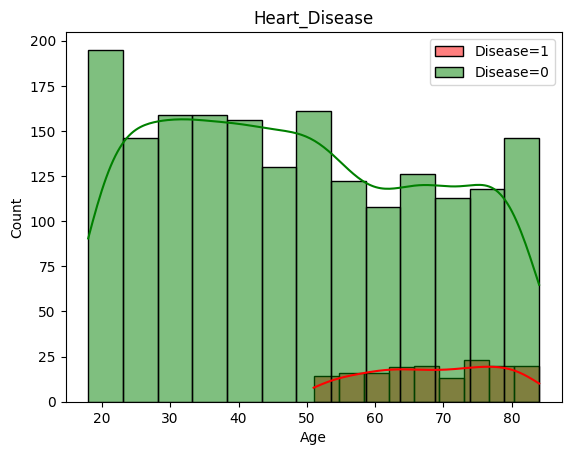

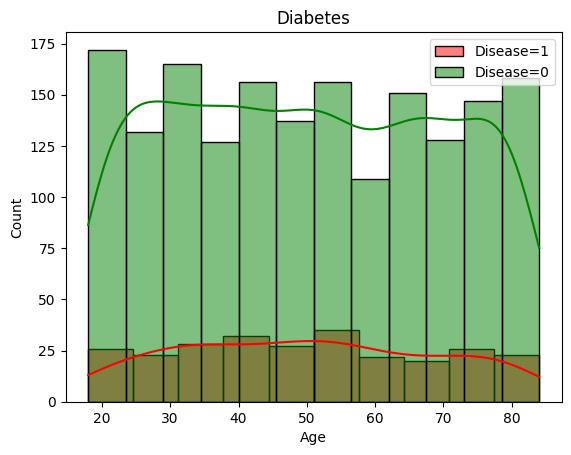

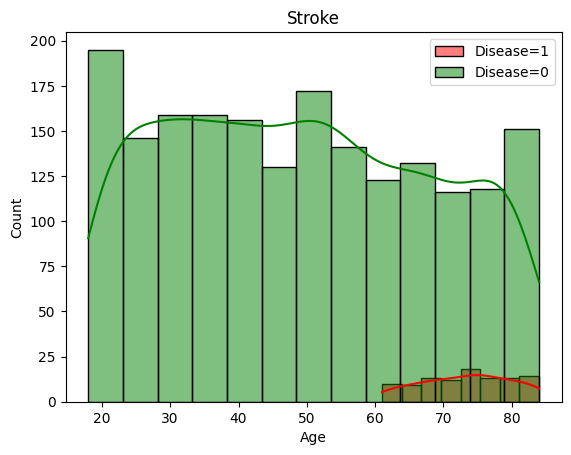

In [13]:
print("\n AGE DISTRIBUTION")

for col in targets:
    sns.histplot(df[df[col]==1]['Age'], color='red', label='Disease=1', kde=True)
    sns.histplot(df[df[col]==0]['Age'], color='green', label='Disease=0', kde=True)
    plt.title(col)
    plt.legend()
    plt.show()


 BMI DISTRIBUTION


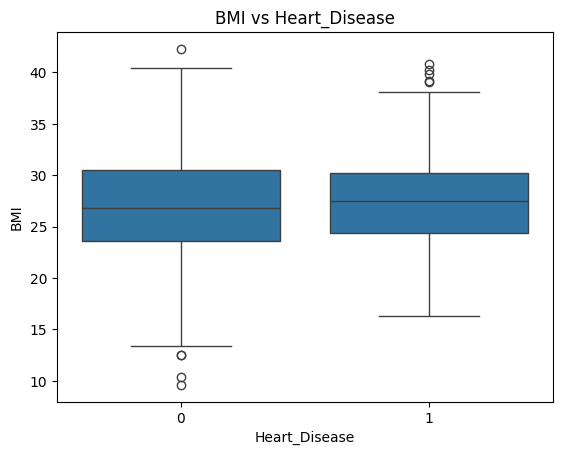

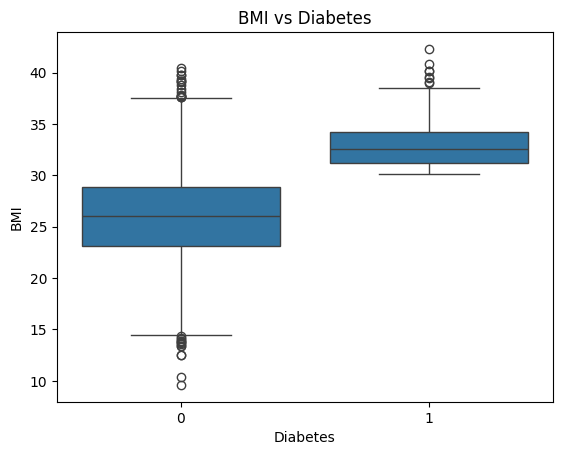

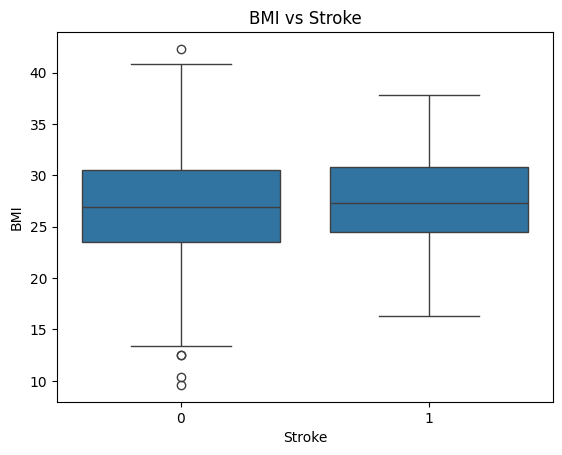

In [14]:
print("\n BMI DISTRIBUTION")

for col in targets:
    sns.boxplot(x=df[col], y=df['BMI'])
    plt.title(f"BMI vs {col}")
    plt.show()


 BLOOD PRESSURE ANALYSIS


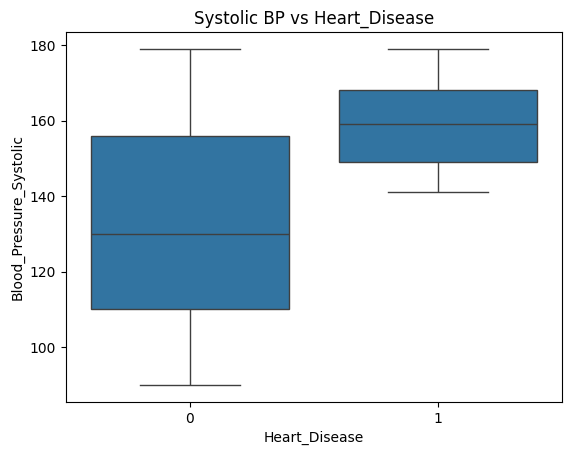

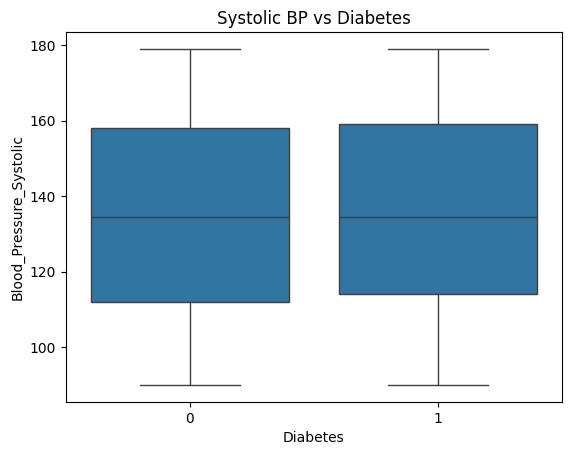

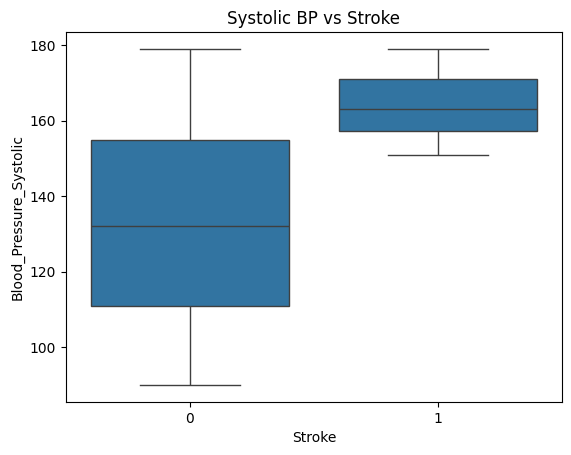

In [15]:
print("\n BLOOD PRESSURE ANALYSIS")

for col in targets:
    sns.boxplot(x=df[col], y=df['Blood_Pressure_Systolic'])
    plt.title(f"Systolic BP vs {col}")
    plt.show()


 LIFESTYLE FACTORS


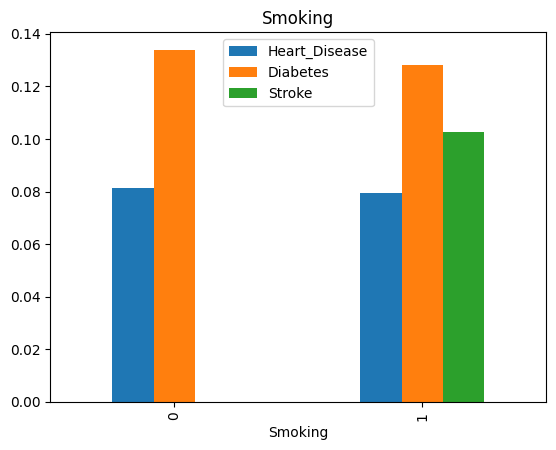

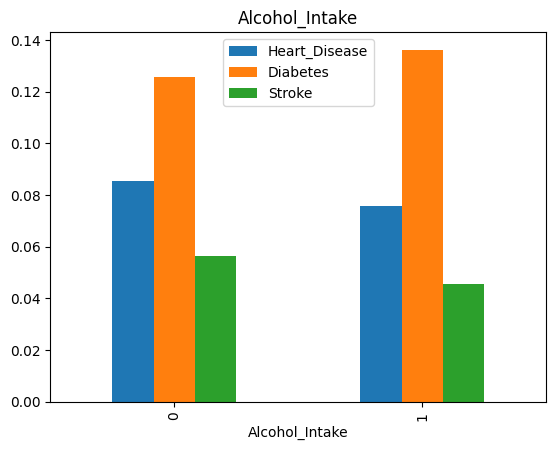

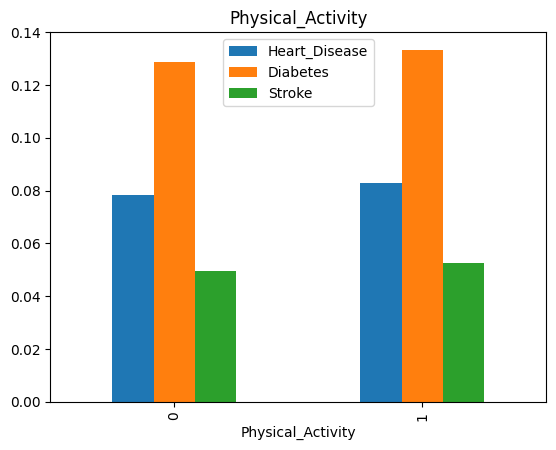

In [16]:
print("\n LIFESTYLE FACTORS")

lifestyle = ['Smoking','Alcohol_Intake','Physical_Activity']

for col in lifestyle:
    df.groupby(col)[targets].mean().plot(kind='bar')
    plt.title(col)
    plt.show()


 METABOLIC FACTORS


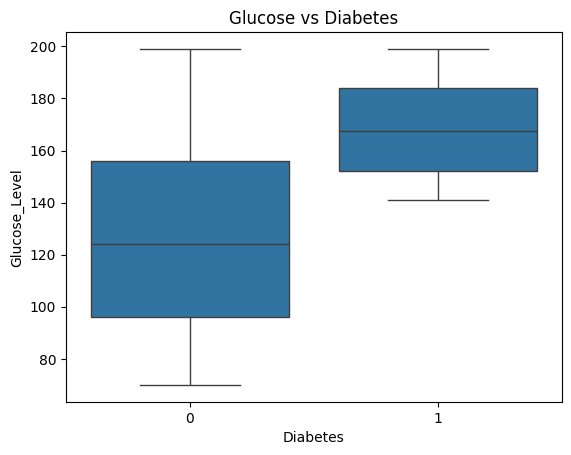

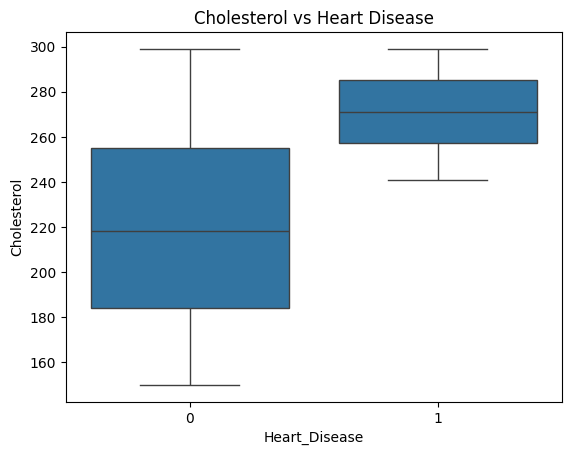

In [17]:
print("\n METABOLIC FACTORS")

sns.boxplot(x=df['Diabetes'], y=df['Glucose_Level'])
plt.title("Glucose vs Diabetes")
plt.show()

sns.boxplot(x=df['Heart_Disease'], y=df['Cholesterol'])
plt.title("Cholesterol vs Heart Disease")
plt.show()


 AGE GROUP ANALYSIS


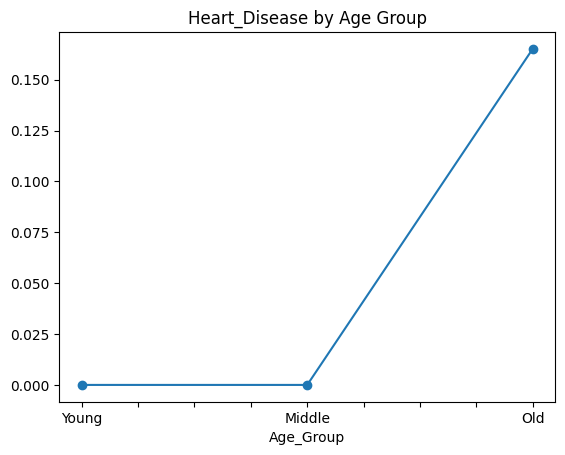

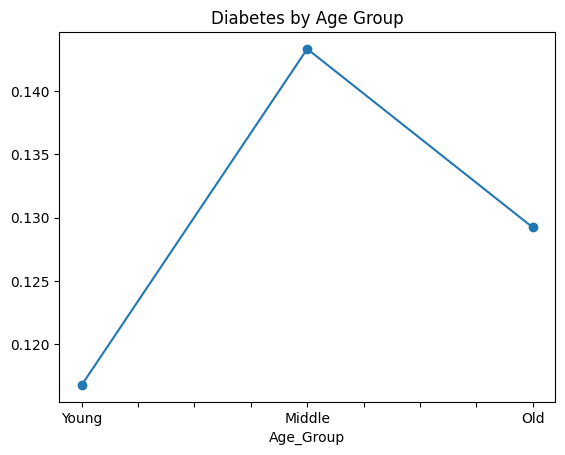

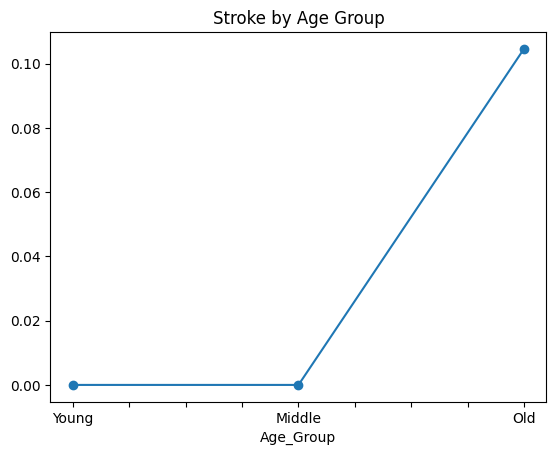

In [18]:
print("\n AGE GROUP ANALYSIS")

df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,50,100], labels=['Young','Middle','Old'])

for col in targets:
    df.groupby('Age_Group')[col].mean().plot(marker='o')
    plt.title(f"{col} by Age Group")
    plt.show()


 AGE × BMI RISK HEATMAP


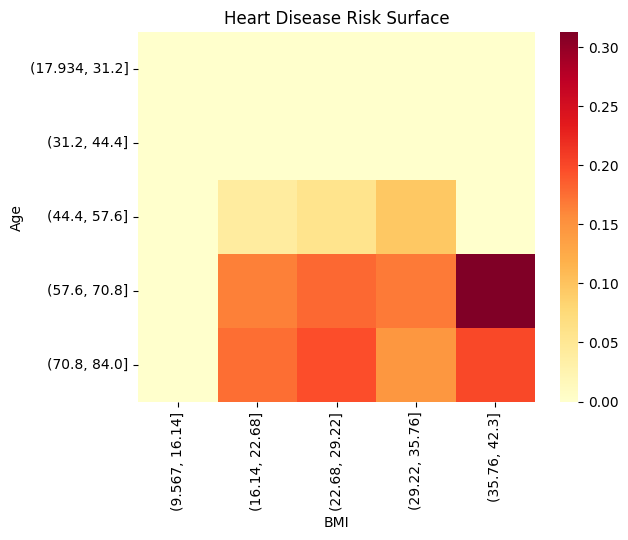

In [19]:
print("\n AGE × BMI RISK HEATMAP")

pivot = df.pivot_table(values='Heart_Disease',
                       index=pd.cut(df['Age'], 5),
                       columns=pd.cut(df['BMI'], 5),
                       aggfunc='mean')

sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Heart Disease Risk Surface")
plt.show()

In [20]:


df['Gender'] = (df['Gender'] == 'Male').astype(int)

features = [
    'Age','Gender','BMI','Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic','Cholesterol','Glucose_Level',
    'Smoking','Alcohol_Intake','Physical_Activity','Family_History'
]

targets = ['Heart_Disease','Diabetes','Stroke']

X = df[features]
y = df[targets]

#  SCALE DATA

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


#  MODELS 

In [22]:


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Logistic": MultiOutputClassifier(LogisticRegression(max_iter=1000)),
    "RandomForest": MultiOutputClassifier(RandomForestClassifier(n_estimators=200)),
    "XGBoost": MultiOutputClassifier(XGBClassifier(eval_metric='logloss')),
    "LightGBM": MultiOutputClassifier(LGBMClassifier(verbose=-1)),
    "CatBoost": MultiOutputClassifier(CatBoostClassifier(verbose=0))
}

results = {}


# TRAIN MODELS

In [23]:

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        "model": model,
        "f1": f1_score(y_test, pred, average='micro'),
        "acc": accuracy_score(y_test, pred)
    }

# BEST MODEL

In [24]:

best_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_name]['model']

print("\n Best Model:", best_name)
print(results)


 Best Model: XGBoost
{'Logistic': {'model': MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000)), 'f1': 0.8235294117647058, 'acc': 0.9175}, 'RandomForest': {'model': MultiOutputClassifier(estimator=RandomForestClassifier(n_estimators=200)), 'f1': 0.9896907216494846, 'acc': 0.995}, 'XGBoost': {'model': MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=N

#  ROC CURVES

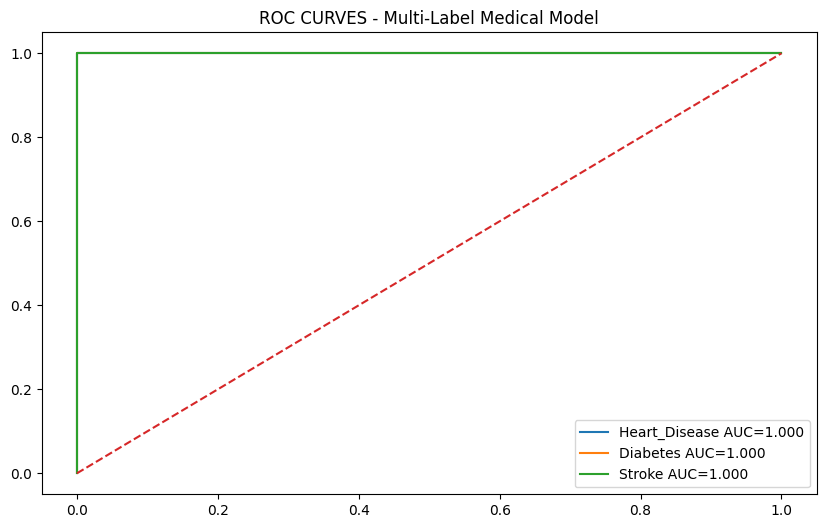

In [25]:


plt.figure(figsize=(10,6))

for i, label in enumerate(targets):
    probs = best_model.estimators_[i].predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test.iloc[:,i], probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} AUC={roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')
plt.title("ROC CURVES - Multi-Label Medical Model")
plt.legend()
plt.show()


#  THRESHOLD TUNING

In [26]:


print("\n THRESHOLD TUNING")

thresholds = np.arange(0.1, 0.9, 0.05)

best_thresholds = {}

for i, label in enumerate(targets):
    probs = best_model.estimators_[i].predict_proba(X_test)[:,1]
    
    best_f1 = 0
    best_t = 0.5
    
    for t in thresholds:
        pred = (probs >= t).astype(int)
        f1 = f1_score(y_test.iloc[:,i], pred)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    best_thresholds[label] = best_t
    print(f"{label}: Best Threshold={best_t:.2f}, F1={best_f1:.3f}")



 THRESHOLD TUNING
Heart_Disease: Best Threshold=0.10, F1=1.000
Diabetes: Best Threshold=0.10, F1=1.000
Stroke: Best Threshold=0.10, F1=1.000


#  SHAP EXPLAINABILITY


 SHAP EXPLANATION (Tree model)


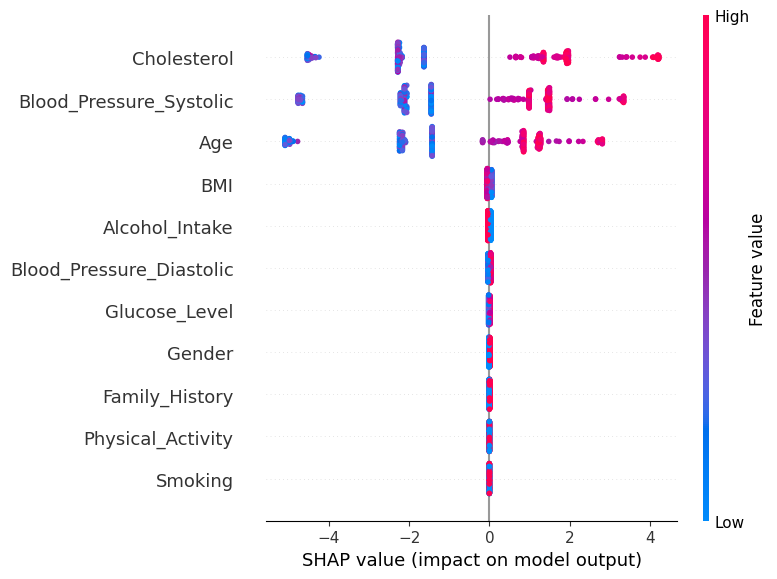

In [27]:

import shap

print("\n SHAP EXPLANATION (Tree model)")

explainer = shap.TreeExplainer(best_model.estimators_[0])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)


#  NEURAL NETWORK (MULTI-LABEL)

In [28]:

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

nn_pred = (nn.predict(X_test) > 0.5).astype(int)

print("\n Neural Network F1:",
      f1_score(y_test, nn_pred, average='micro'))



2026-04-16 16:54:08.786585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776358449.119538      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776358449.213841      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776358450.077930      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776358450.077978      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776358450.077981      16 computation_placer.cc:177] computation placer alr

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

 Neural Network F1: 0.8125


#  FINAL COMPARISON

In [29]:

print("\n FINAL MODEL COMPARISON")

for name, res in results.items():
    print(f"{name}: F1={res['f1']:.3f}, ACC={res['acc']:.3f}")

print("Neural Network: (see above)")



 FINAL MODEL COMPARISON
Logistic: F1=0.824, ACC=0.917
RandomForest: F1=0.990, ACC=0.995
XGBoost: F1=1.000, ACC=1.000
LightGBM: F1=1.000, ACC=1.000
CatBoost: F1=1.000, ACC=1.000
Neural Network: (see above)


#  SIMPLE PREDICTION FUNCTION

In [30]:
def predict_patient(patient_data, model, scaler, feature_columns, targets):
   

    # Convert input to DataFrame
    df_input = pd.DataFrame([patient_data])

    # Encode Gender
    df_input['Gender'] = (df_input['Gender'] == 'Male').astype(int)


    df_input = df_input[feature_columns]

    
    df_input_scaled = scaler.transform(df_input)

    prediction = model.predict(df_input_scaled)[0]

    
    result = {}
    for i, disease in enumerate(targets):
        result[disease] = "HIGH RISK " if prediction[i] == 1 else "LOW RISK "

    return result

In [31]:
patient = {
    'Age': 60,
    'Gender': 'Male',
    'BMI': 31,
    'Blood_Pressure_Systolic': 150,
    'Blood_Pressure_Diastolic': 95,
    'Cholesterol': 240,
    'Glucose_Level': 160,
    'Smoking': 1,
    'Alcohol_Intake': 1,
    'Physical_Activity': 0,
    'Family_History': 1
}

result = predict_patient(patient, best_model, scaler, features, targets)

print("\n PATIENT RISK REPORT")
for k, v in result.items():
    print(f"{k}: {v}")


 PATIENT RISK REPORT
Heart_Disease: LOW RISK 
Diabetes: HIGH RISK 
Stroke: LOW RISK 
